# **Proyecto 1**

In [152]:
# Manejo de datos
import pandas as pd
import numpy as np
import missingno as msno


# Visualizaciones
import seaborn as sns
import matplotlib.pyplot as plt
import math

# Preprocesamiento y Herramientas de Selección
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV


# Modelos
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
    ExtraTreesRegressor,
    StackingRegressor,
    VotingRegressor
)

# Métricas de Evaluación
from sklearn.metrics import (
    mean_absolute_error,mean_squared_error,r2_score
)


# 1. Análisis preliminar de variables

# 1.1 Leer el archivo

In [ ]:
# 1. Leer el archivo
# Carga de datos de archivo .csv
dataTraining = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2025/main/datasets/dataTrain_Spotify.csv')
dataTesting = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2025/main/datasets/dataTest_Spotify.csv', index_col=0)


# 1.2 Estadísticas descriptivas

In [125]:
dataTraining.drop(columns='Unnamed: 0',inplace=True)

In [91]:
dataTraining.describe(include='all')

,Unnamed: 0,track_id,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity
count,79800.000000,79800,79800,79800,79800,7.980000e+04,79800,79800.000000,79800.000000,79800.000000,...,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800,79800.000000
unique,NaN,66720,25775,37315,55767,NaN,2,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,114,NaN
top,NaN,5ftfVzSLIi5ZxYdNbRtf41,The Beatles,Alternative Christmas 2022,Run Rudolph Run,NaN,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,progressive-house,NaN
freq,NaN,7,194,131,115,NaN,72962,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,738,NaN
mean,39899.500000,NaN,NaN,NaN,NaN,2.279022e+05,NaN,0.567318,0.641529,5.307043,...,0.637732,0.084750,0.314979,0.157319,0.213313,0.474267,122.076559,3.902556,NaN,33.265301
std,23036.420078,NaN,NaN,NaN,NaN,1.050599e+05,NaN,0.173110,0.251441,3.562186,...,0.480659,0.105657,0.332512,0.310792,0.190075,0.259010,29.941937,0.434284,NaN,22.330871
min,0.000000,NaN,NaN,NaN,NaN,1.338600e+04,NaN,0.000000,0.000019,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000
25%,19949.750000,NaN,NaN,NaN,NaN,1.744360e+05,NaN,0.456000,0.472000,2.000000,...,0.000000,0.035900,0.017000,0.000000,0.097900,0.261000,99.081250,4.000000,NaN,17.000000
50%,39899.500000,NaN,NaN,NaN,NaN,2.128130e+05,NaN,0.581000,0.685000,5.000000,...,1.000000,0.049000,0.169000,0.000041,0.132000,0.464000,122.009000,4.000000,NaN,35.000000
75%,59849.250000,NaN,NaN,NaN,NaN,2.614260e+05,NaN,0.695000,0.854000,8.000000,...,1.000000,0.084500,0.598000,0.050500,0.273000,0.684000,140.054000,4.000000,NaN,50.000000


In [92]:
# Verificar si hay duplicados o nulos

print(f"En el dataset hay ",dataTraining.duplicated().sum()," valores duplicados")
print(f"En el dataset hay ",dataTraining.isnull().sum().sum()," valores nulos")

En el dataset hay  0  valores duplicados
En el dataset hay  0  valores nulos


# 1.3 Distribución de la variable objetivo

array([[<Axes: title={'center': 'duration_ms'}>,
        <Axes: title={'center': 'danceability'}>,
        <Axes: title={'center': 'energy'}>,
        <Axes: title={'center': 'key'}>],
       [<Axes: title={'center': 'loudness'}>,
        <Axes: title={'center': 'mode'}>,
        <Axes: title={'center': 'speechiness'}>,
        <Axes: title={'center': 'acousticness'}>],
       [<Axes: title={'center': 'instrumentalness'}>,
        <Axes: title={'center': 'liveness'}>,
        <Axes: title={'center': 'valence'}>,
        <Axes: title={'center': 'tempo'}>],
       [<Axes: title={'center': 'time_signature'}>,
        <Axes: title={'center': 'popularity'}>, <Axes: >, <Axes: >]],
      dtype=object)

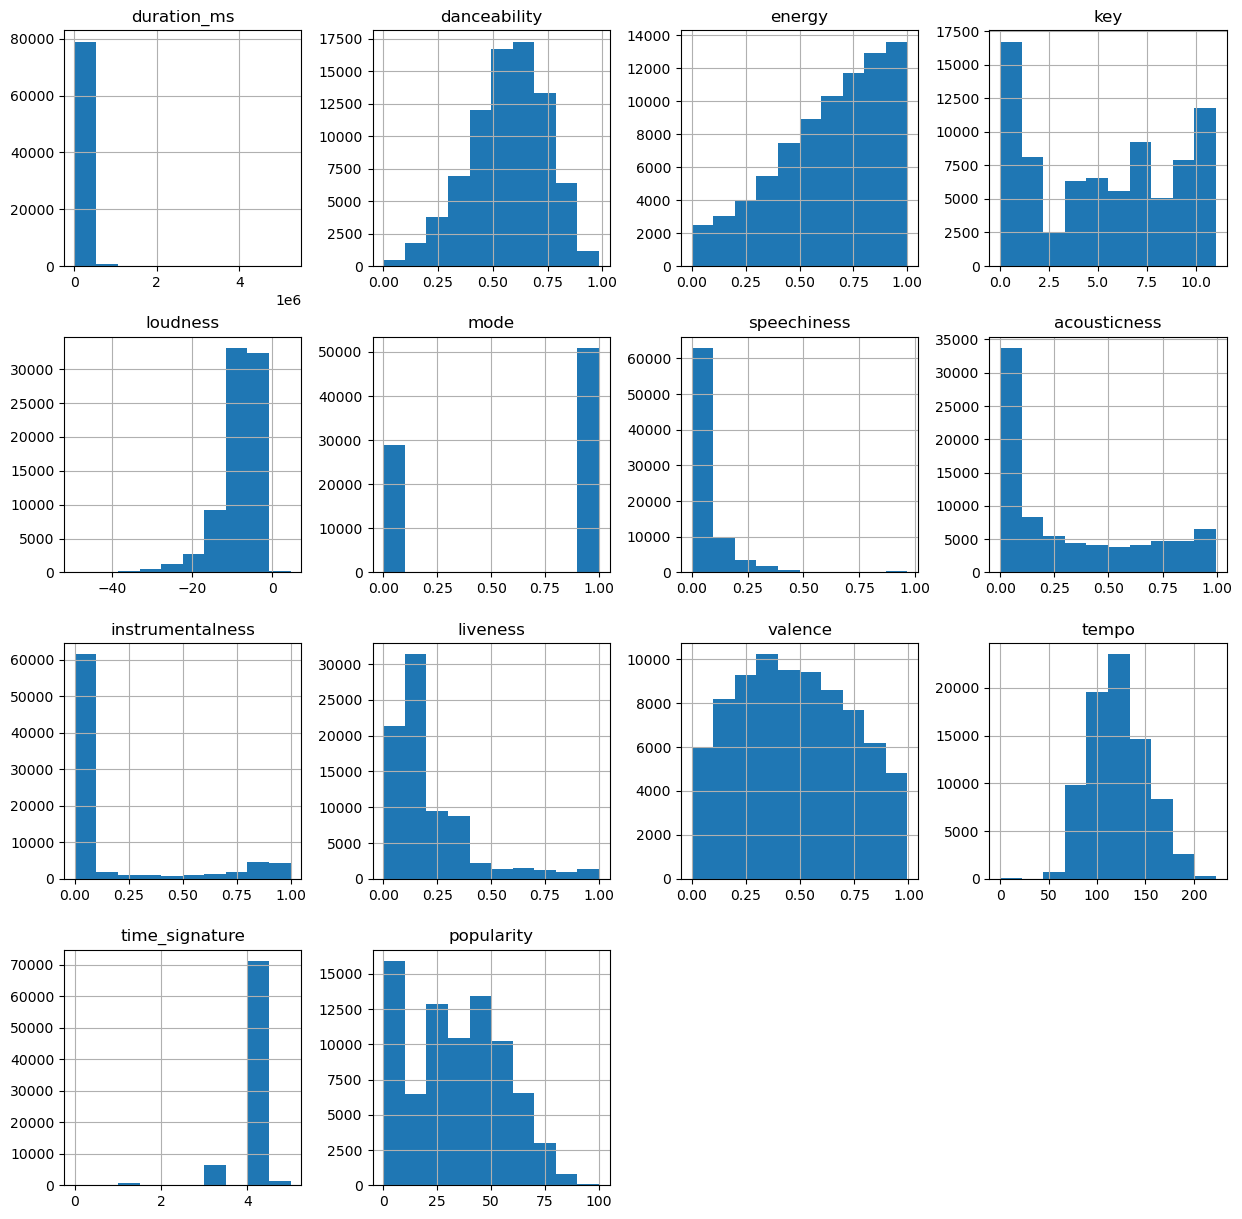

In [ ]:
dataTraining.hist(
    figsize=(15,15)
)

<Axes: >

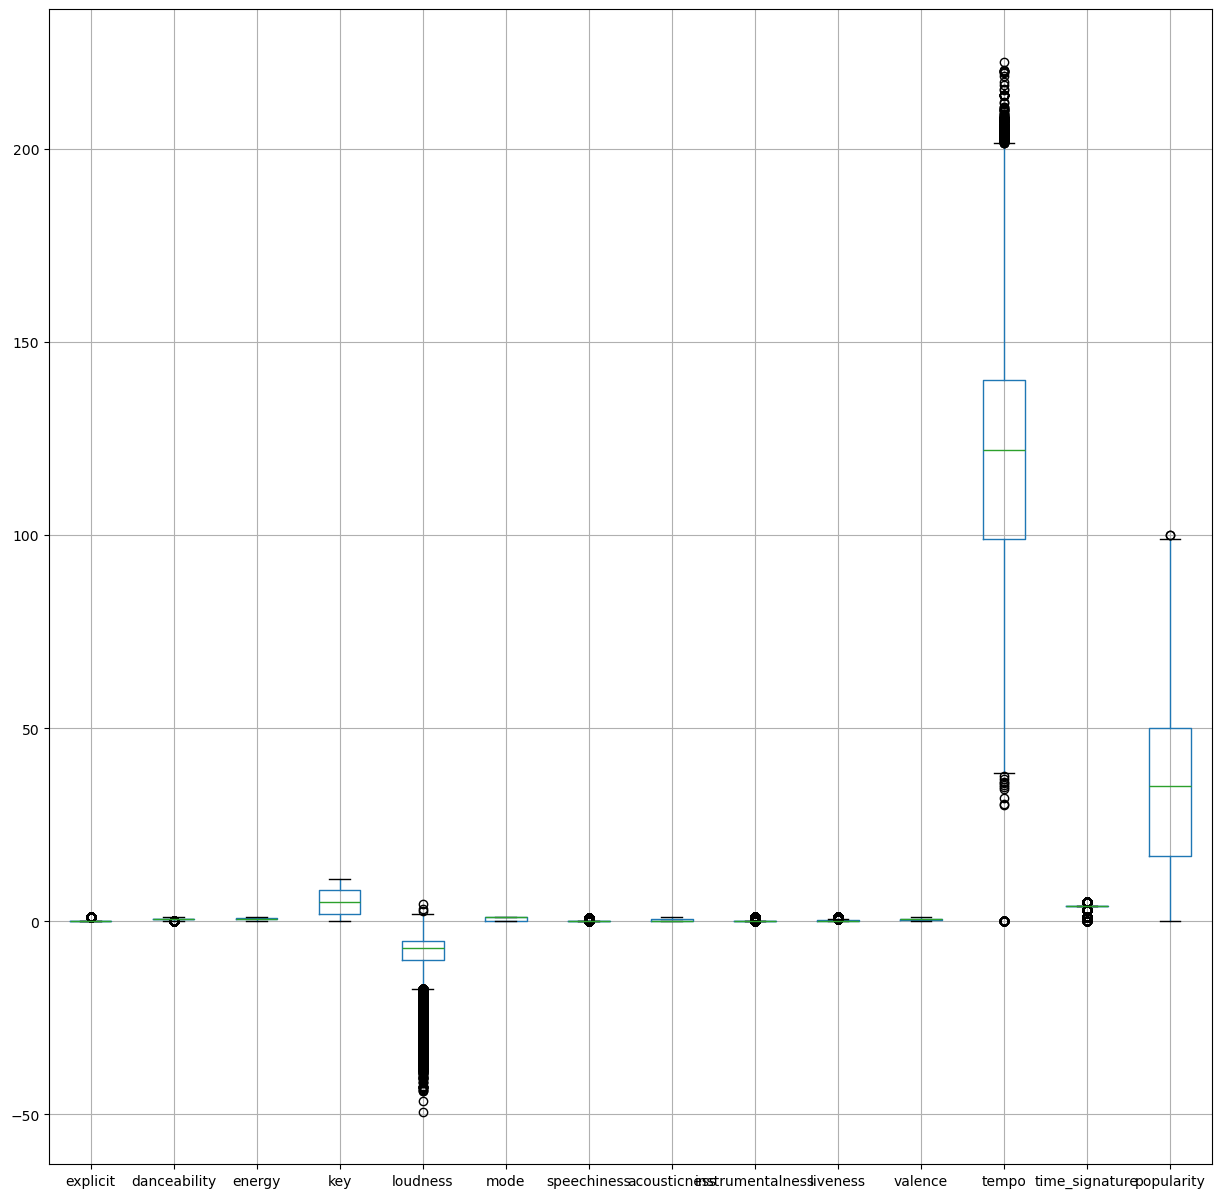

In [131]:
dataTraining.drop(columns='duration_ms').boxplot(
    figsize=(15,15)
)

Text(0, 0.5, 'Frecuencia')

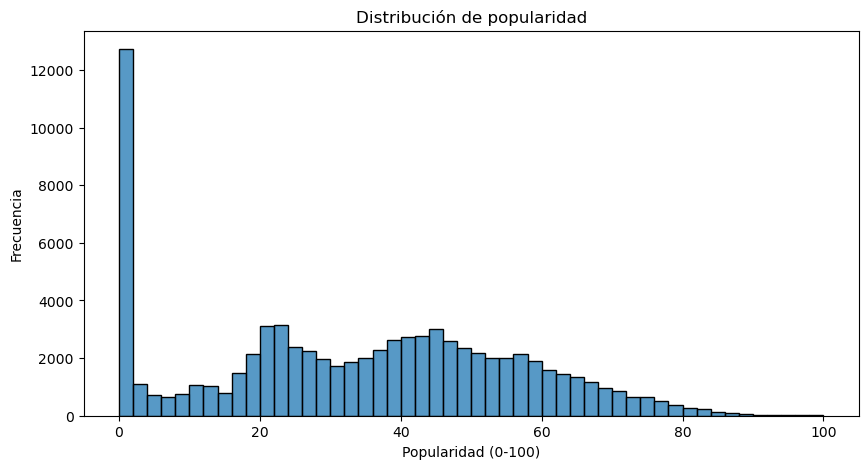

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    dataTraining['popularity'],
    bins=50
)

plt.title("Distribución de popularidad")
plt.xlabel("Popularidad (0-100)")
plt.ylabel("Frecuencia")

In [94]:
df=dataTraining.drop(labels=['track_id','track_name','album_name'],axis=1)

In [ ]:
# Se cambian los valores True y False de cada modelo para que sean float y así poderlos analizar en el modelo

mapeo={
    True:1,
    False:0
}

df['explicit']=df['explicit'].map(mapeo)

In [ ]:
# La variable artista es valiosa pero categórica, por lo que se utiliza una metodología de asignarles un valor de popularidad según su promedio de popularidad

artists_by_pop=df.groupby('artists').popularity.agg('mean')

df['artists_pop_mean']=df['artists'].map(artists_by_pop)
df.drop(columns='artists',inplace=True)

In [ ]:
# El género puede influir en la popularidad, pero al ser categórica debe transformarse mediante un label encoding usando dummies de Pandas

df=pd.get_dummies(
    df,
    columns=['track_genre'],
    dtype=float
)

In [105]:
df.shape

(79800, 131)

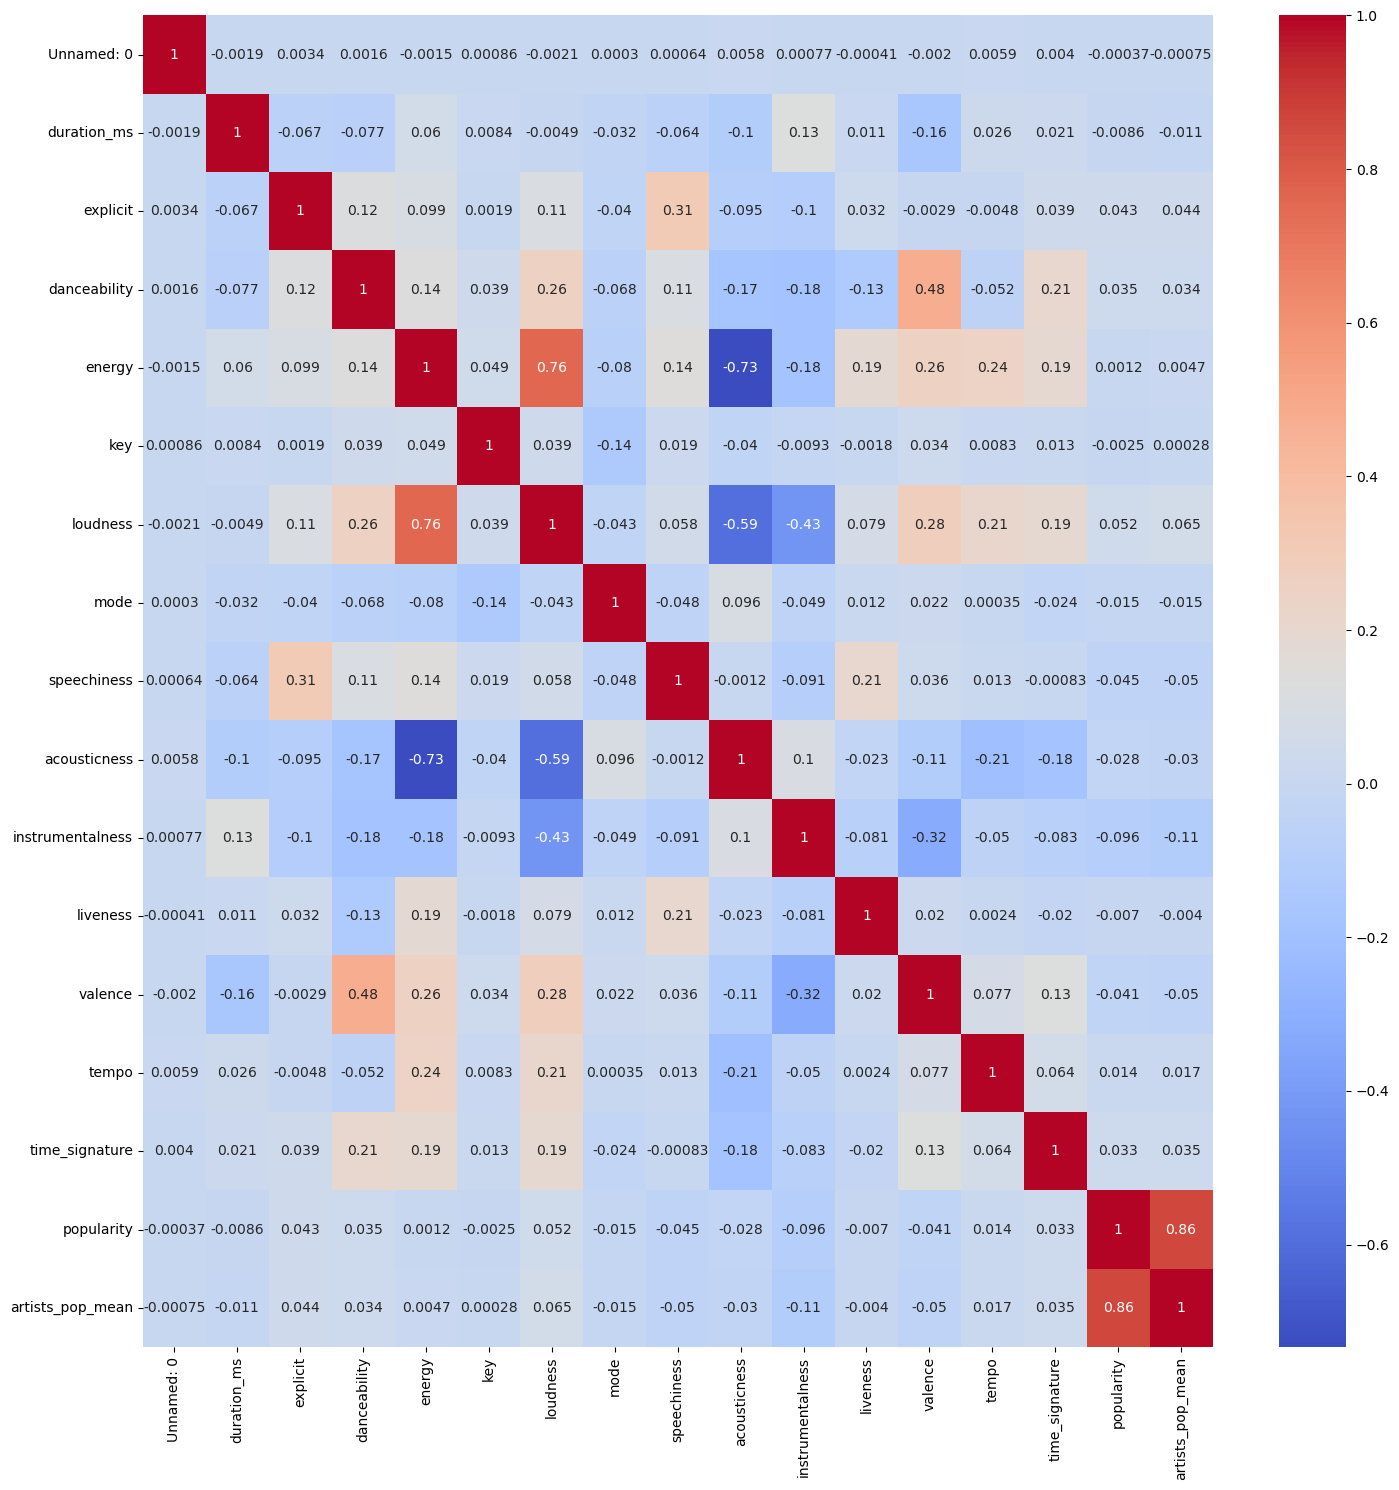

In [103]:
# Se verifica la relación lineal entre todas las variables

fig, ax = plt.subplots(figsize=(15, 15))

# Selecciona solo columnas que NO empiezan con 'track_'
cols_to_plot = [col for col in df.columns if not col.startswith('track_')]
df_filtered = df[cols_to_plot].select_dtypes(include="number")

sns.heatmap(
    data=df_filtered.corr(),
    cmap='coolwarm',
    annot=True
)
plt.tight_layout()
plt.show()

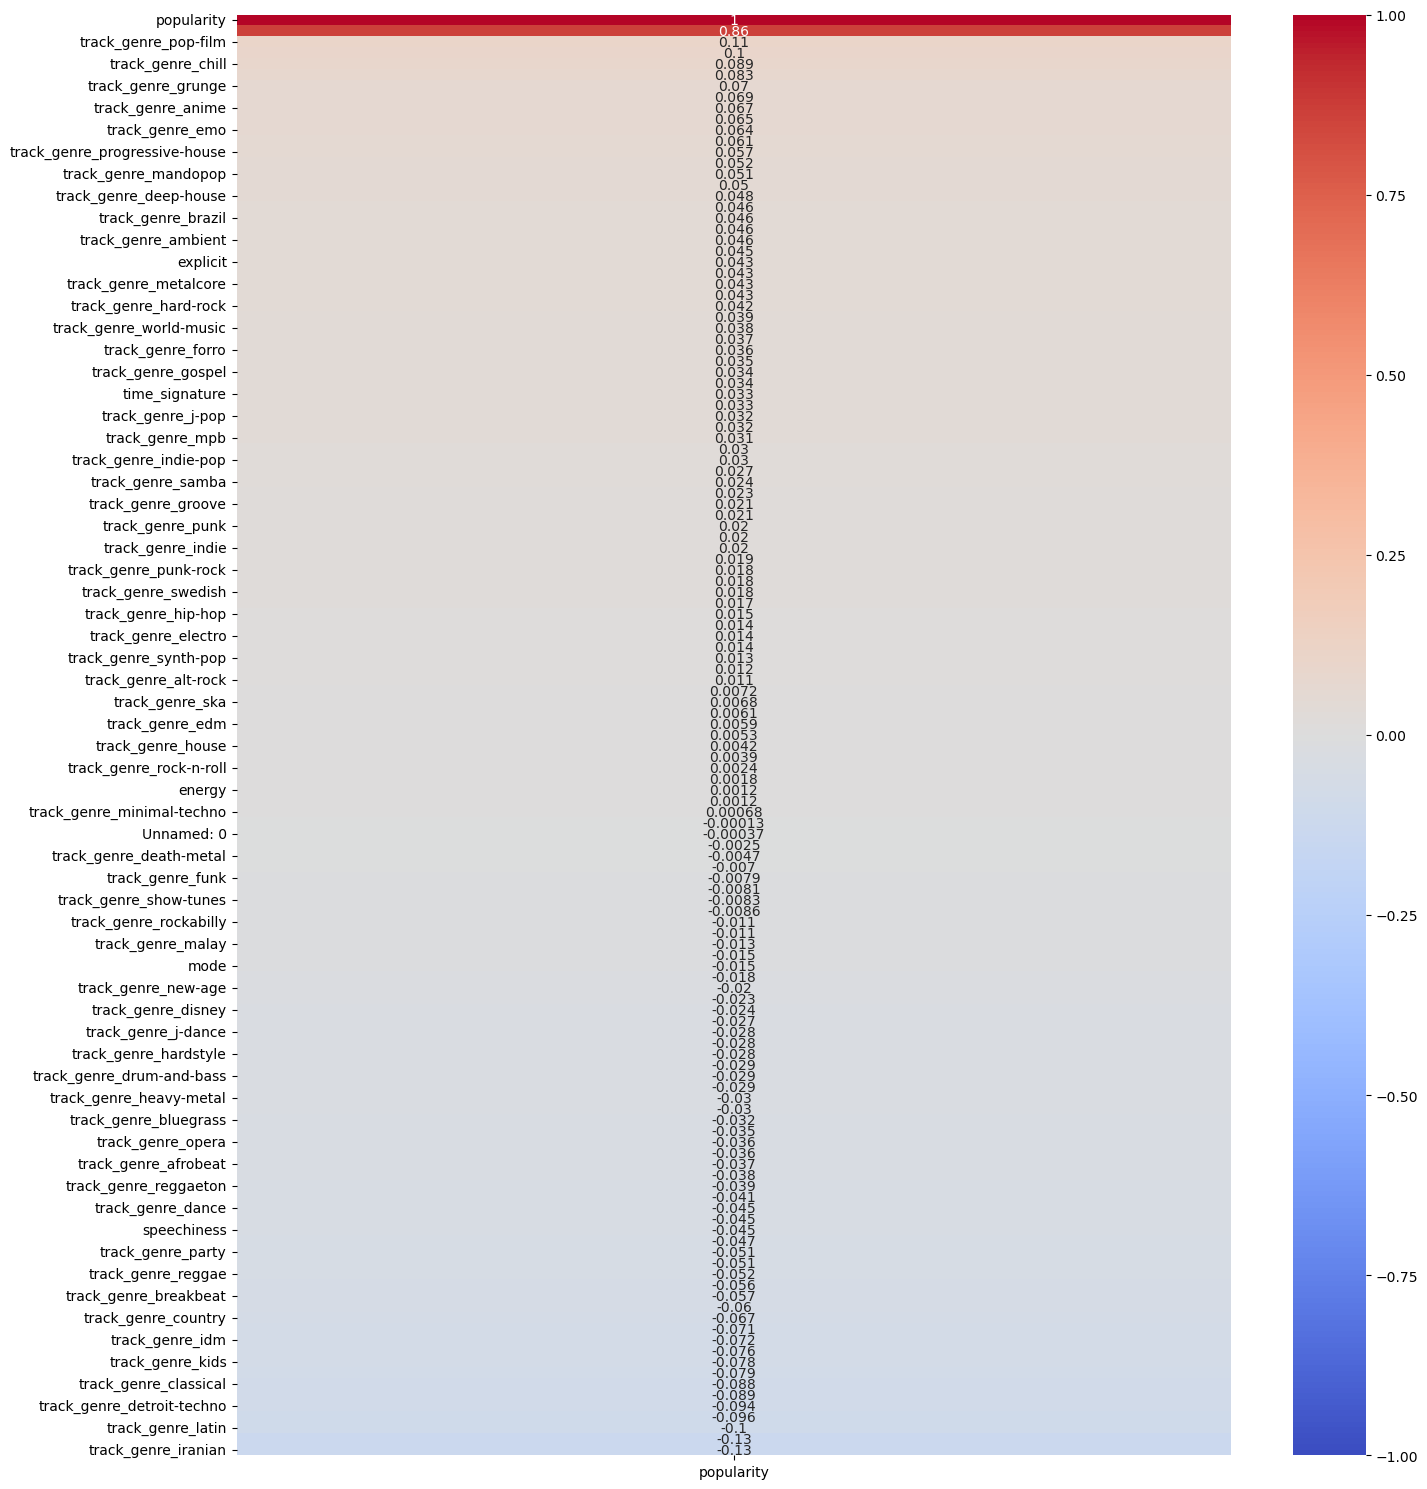

In [102]:
# Se filtra especificamente la correlación que tienen las variables con `popularity` 
plt.figure(figsize=(15,15))

corr_pop = df.select_dtypes(include="number").corr()[['popularity']].sort_values(by='popularity', ascending=False)
sns.heatmap(corr_pop, annot=True, cmap='coolwarm',vmin=-1,vmax=1)
plt.tight_layout()

## Conclusiones - Estadísticas descriptivas

Columnas categóricas con muchos registros únicos como `track_id`,`track_name` y `album_name` no aportan valor real al objetivo y añadirlas con metodologías tipo encoding aumentaría el costo computacional sin valor real, por lo que fueron eliminadas. 

# 2. Preprocesamiento de datos

In [112]:
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns='popularity'),df['popularity'],test_size=0.3,random_state=42)

In [160]:
param_grid = {
    'min_samples_split': [100,300, 500, 50, 1000],
    'max_depth': [1, 2, 3, 4,5],
    'min_samples_leaf': [100, 300, 500, 50, 1000]
}

modelo = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42,splitter='best',criterion='squared_error'),
    param_grid=param_grid,
    cv=2,
    scoring='neg_root_mean_squared_error'
)

modelo.fit(x_train,y_train)


GridSearchCV(cv=2, estimator=DecisionTreeRegressor(random_state=42),
             param_grid={'max_depth': [1, 2, 3, 4, 5],
                         'min_samples_leaf': [100, 300, 500, 50, 1000],
                         'min_samples_split': [100, 300, 500, 50, 1000]},
             scoring='neg_root_mean_squared_error')

In [161]:
y_pred=modelo.predict(x_test)

In [162]:
rmse_dtr=np.sqrt(mean_squared_error(y_test,y_pred))
mae_dtr=mean_absolute_error(y_test,y_pred)
r2_dtr=r2_score(y_test,y_pred)

print(f"El RMSE obtenido es de {rmse_dtr} puntos de popularidad")
print(f"El MAE obtenido es de {mae_dtr}")
print(f"El r2 obtenido es de {r2_dtr}")

El RMSE obtenido es de 11.293405275147771 puntos de popularidad
El MAE obtenido es de 5.917600849918326
El r2 obtenido es de 0.7428623592684147


In [ ]:
rmse_dtr=np.sqrt(mean_squared_error(y_test,y_pred))
mae_dtr=mean_absolute_error(y_test,y_pred)
r2_dtr=r2_score(y_test,y_pred)

print(f"El RMSE obtenido es de {rmse_dtr} puntos de popularidad")
print(f"El MAE obtenido es de {mae_dtr}")
print(f"El r2 obtenido es de {r2_dtr}")

El RMSE obtenido es de 15.11193268934691
El MAE obtenido es de 7.144778613199666
El r2 obtenido es de 0.5395782312672515


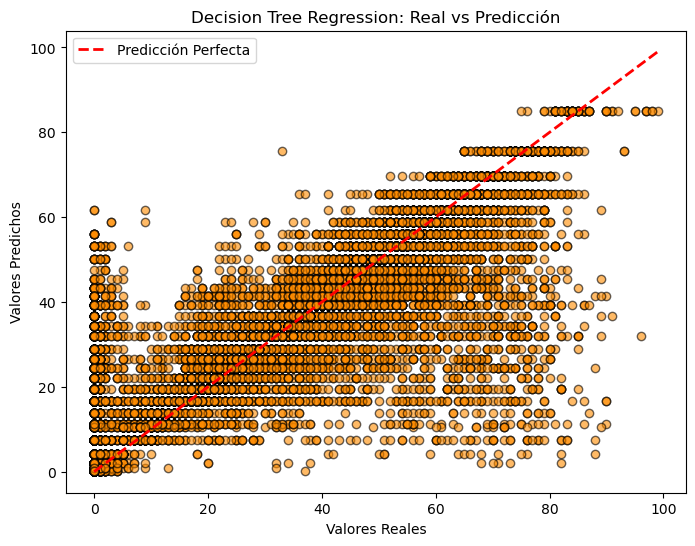

In [163]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, edgecolor="black", c="darkorange", alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Predicción Perfecta")
plt.xlabel("Valores Reales")
plt.ylabel("Valores Predichos")
plt.title("Decision Tree Regression: Real vs Predicción")
plt.legend()
plt.show()

In [165]:
# Preprocesamiento de dataTesting
df_test = dataTesting.copy()

df_test = df_test.drop(columns=['track_id', 'track_name', 'album_name'])

df_test['explicit'] = df_test['explicit'].map({True: 1, False: 0})

df_test['artists_pop_mean'] = df_test['artists'].map(artists_by_pop)
df_test.drop(columns='artists', inplace=True)

df_test = pd.get_dummies(df_test, columns=['track_genre'], dtype=float)

# Alinear columnas con el training (por si hay géneros que no aparecen en test)
df_test = df_test.reindex(columns=x_train.columns, fill_value=0)

# Predicción y exportación
y_pred_final = modelo.predict(df_test)

y_pred_kaggle = pd.DataFrame(
    y_pred_final, 
    index=dataTesting.index, 
    columns=['Popularity']
)

y_pred_kaggle.to_csv('submission_file.csv', index_label='ID')
y_pred_kaggle.head()

,Popularity
0,43.364725
1,11.317495
2,0.065089
3,7.568303
4,26.624357
